# Phase 1: what was known, and when

Every macro series enters as its **full revision history** from ALFRED: one row per observation per vintage window.
"What did the world know on date X" is one boolean mask (`VintageFrame.as_of`), so no downstream number can be built on
a revision that did not yet exist. The Treasury side (auctions, the Monthly Statement of the Public Debt, interest
expense, debt to the penny) is dated by publication and filtered the same way.

Decision record: `docs/decisions/0002-full-alfred-vintages.md`.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display, Markdown
import bond_sim.notebook as nb
pd.set_option("display.width", 170); pd.set_option("display.max_columns", 40); pd.set_option("display.max_rows", 80)
plt.rcParams["figure.dpi"] = 110

# ── parameters: change and rerun ─────────────────────────────────────────────
AS_OF = pd.Timestamp("2026-09-15")     # every loader filters on this date (point-in-time contract)
K = 1000                                 # Monte Carlo paths (raise for the paper)
FORCE_REFRESH = False                  # True re-downloads every series and rebuilds cached steps
os.environ["BOND_SIM_CACHE"] = "0" if FORCE_REFRESH else "1"
import bond_sim.config as bcfg
CFG_HASH = bcfg.load().content_hash()   # every cached step is keyed by the configuration that produced it
ctx = nb.cached(f"ctx_{AS_OF.date()}_{CFG_HASH}", lambda: nb.load_context(AS_OF), refresh=FORCE_REFRESH)
print(ctx.grid, "| config hash", CFG_HASH, "| series:", ctx.w.shape[1])

MonthlyGrid(1980-01-01 .. 2056-09-01, M=921) | config hash d9222bd624fd | series: 48


## 1.1 The registry

Every series id below was resolved against the FRED API when it was added (title, frequency, units, range recorded
from the response). `pub_lag_days` is the conservative publication lag used only for observations older than the
series' first ALFRED vintage.

In [2]:
from bond_sim.data import SERIES
reg = pd.DataFrame([{"id": s.id, "group": s.group, "freq": s.freq, "units": s.units, "pub_lag_days": s.pub_lag_days,
                     "title": s.title} for s in SERIES.values()]).set_index("id")
display(reg.groupby("group").size().rename("n_series").to_frame().T)
display(reg.sort_values(["group", "id"]))

group,consumer,corporate,financial,fiscal,holders,labor,macro,prices,rates
n_series,6,6,5,11,3,15,2,4,8


,group,freq,units,pub_lag_days,title
id,,,,,
DSPIC96,consumer,M,Bil. of Chn. 2017 $,32,Real Disposable Personal Income (SAAR)
PCE,consumer,M,Bil. of $,32,Personal Consumption Expenditures (SAAR)
PSAVERT,consumer,M,%,32,Personal Saving Rate
REVOLSL,consumer,M,Mil. of $,40,Revolving Consumer Credit Owned and Securitized
TOTALSL,consumer,M,Mil. of $,40,Total Consumer Credit Owned and Securitized
UMCSENT,consumer,M,Index 1966:Q1=100,5,University of Michigan Consumer Sentiment (NSA)
BUSLOANS,corporate,M,Bil. of $,12,"Commercial and Industrial Loans, All Commercia..."
CP,corporate,Q,Bil. of $,65,Corporate Profits After Tax (SAAR)
INDPRO,corporate,M,Index 2017=100,18,Industrial Production: Total Index


## 1.2 Revisions are large and slow

GDP for 2009Q3 was first published at 14,301.5 and revised five times. An analysis dated November 2009 must see the
first number. Below, the same series as it was known on four different dates.

,series_id,date,value,realtime_start,realtime_end,backfilled
0,GDP,2009-07-01,14301.500,2009-10-29,2009-11-23,False
1,GDP,2009-07-01,14266.300,2009-11-24,2009-12-21,False
2,GDP,2009-07-01,14242.100,2009-12-22,2010-07-29,False
3,GDP,2009-07-01,14114.700,2010-07-30,2011-07-28,False
4,GDP,2009-07-01,13920.500,2011-07-29,2012-07-26,False
5,GDP,2009-07-01,13952.200,2012-07-27,2013-07-30,False
6,GDP,2009-07-01,14384.400,2013-07-31,2014-07-29,False
7,GDP,2009-07-01,14384.100,2014-07-30,2017-10-26,False
8,GDP,2009-07-01,14384.145,2017-10-27,2018-07-26,False
9,GDP,2009-07-01,14420.312,2018-07-27,2021-07-28,False


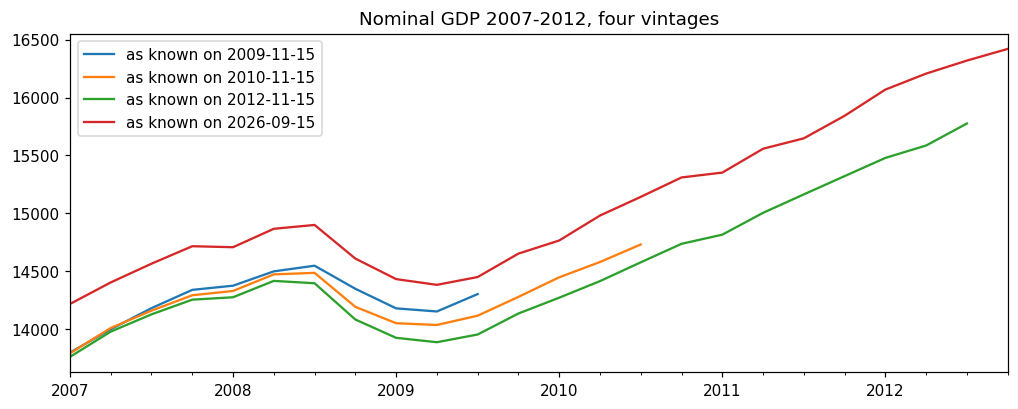

In [3]:
from bond_sim.data import FredClient
fc = FredClient()
gdp = fc.fetch_vintages("GDP")
display(gdp.revisions("GDP", "2009-07-01"))
fig, ax = plt.subplots(figsize=(11, 4))
for d in ("2009-11-15", "2010-11-15", "2012-11-15", str(AS_OF.date())):
    v = gdp.as_of(d).set_index("date")["value"]
    v.loc["2007":"2012"].plot(ax=ax, label=f"as known on {d}")
ax.set_title("Nominal GDP 2007-2012, four vintages"); ax.legend(); ax.set_xlabel(""); plt.show()

## 1.3 Where true vintages start, and what is backfilled

ALFRED tracks GDP from 1991-12, daily yields from 2005-07, the monthly Treasury Statement from 2015-11. Older
observations carry the first vintage's date, which is not when they were published; those rows are re-stamped with
`date + pub_lag_days` and flagged `backfilled`. The table is the paper's data appendix.

,freq,first_obs,first_true_vintage,n_obs,n_vintage_rows,backfilled_share,pub_lag_days_assumed
series_id,,,,,,,
GFDEBTN,Q,1966-01-01,1997-03-24,241,264,0.510,10
FYGFDPUN,Q,1970-01-01,1997-03-24,225,263,0.476,10
GFDEGDQ188S,Q,1966-01-01,2012-12-06,241,1264,0.772,35
FYGFGDQ188S,Q,1970-01-01,2012-12-06,225,1198,0.756,35
MTSDS133FMS,M,1980-10-01,2015-11-12,551,777,0.760,14
MTSR133FMS,M,1980-10-01,2015-11-12,551,747,0.760,14
MTSO133FMS,M,1980-10-01,2015-11-12,551,777,0.760,14
A091RC1Q027SBEA,Q,1947-01-01,2013-04-26,318,1214,0.830,35
FYOIGDA188S,A,1940-01-01,2013-01-30,86,433,0.837,120


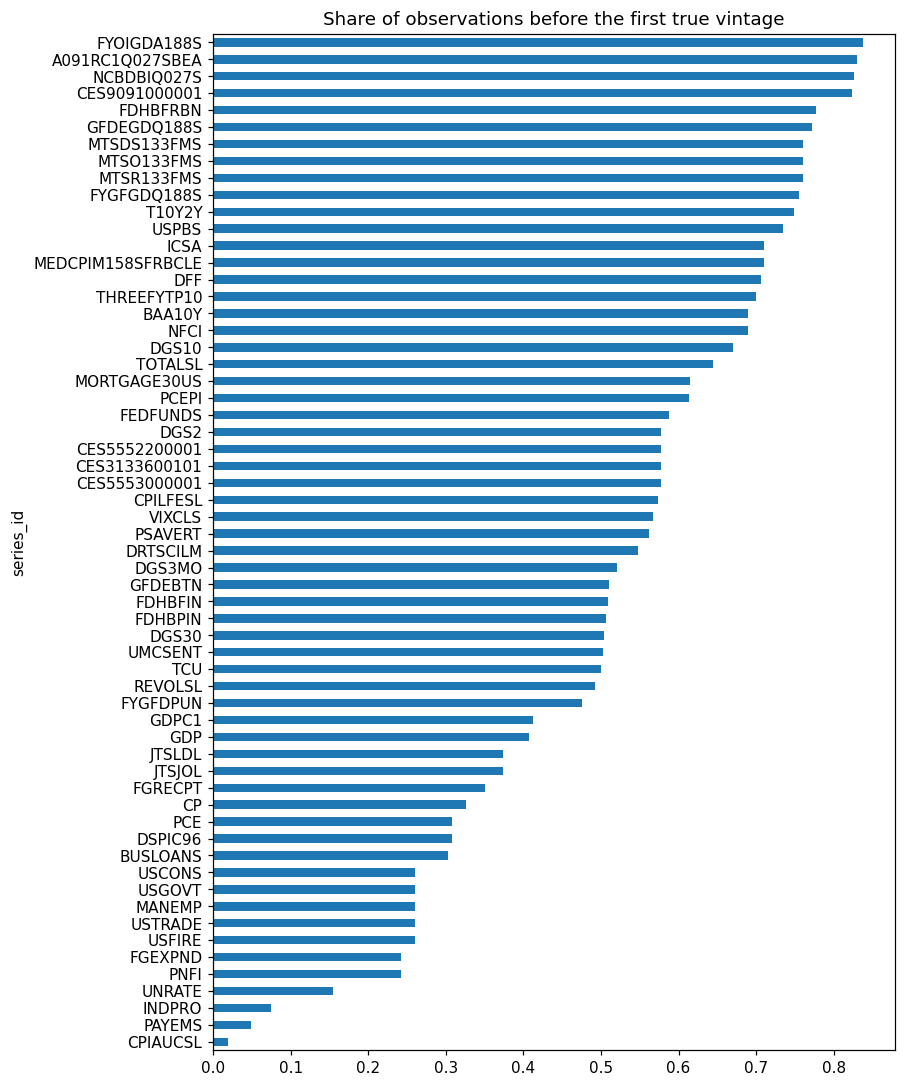

In [4]:
cov = nb.cached("vintage_coverage", lambda: fc.vintage_coverage(list(SERIES)), refresh=FORCE_REFRESH)
cov["backfilled_share"] = cov["n_backfilled_obs"] / cov["n_obs"]
display(cov[["freq", "first_obs", "first_true_vintage", "n_obs", "n_vintage_rows", "backfilled_share", "pub_lag_days_assumed"]].round(3))
ax = cov["backfilled_share"].sort_values().plot.barh(figsize=(8, 12)); ax.set_title("Share of observations before the first true vintage"); plt.show()

## 1.4 The Treasury ledger

The auction dataset is the primitive the bond book is built from: 11,113 auctions since 1979-11 with issue and maturity
dates, coupon (notes/bonds), discount rate (bills), and accepted amounts. Two facts that had to be established by probing
rather than assumed: `total_accepted` already includes SOMA add-ons (adding `soma_accepted` overstated issuance on every
CUSIP checked), and the MSPD detail table's CUSIP column also carries subtotal labels.

11,113 auctions, 5,084 CUSIPs, 1979-11-15 .. 2026-09-18


,auctions,cusips,gross_issuance_tn
kind,,,
bill,8330,3010,257.06
bond,394,171,6.18
frn,154,51,3.23
note,1967,1743,56.00
tips,268,109,3.36


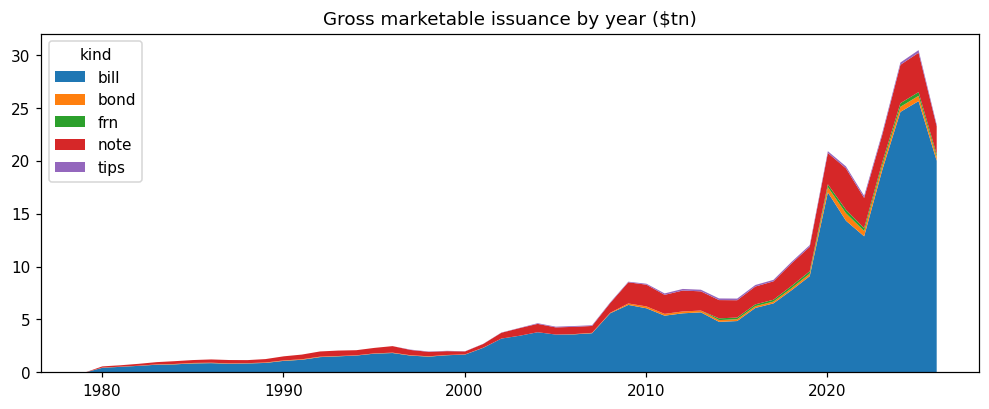

In [5]:
from bond_sim.data import load_auctions
au = load_auctions(as_of=AS_OF)
au["kind"] = np.where(au.security_type.eq("Bill"), "bill", np.where(au.inflation_index_security, "tips",
             np.where(au.floating_rate, "frn", np.where(au.security_type.eq("Bond"), "bond", "note"))))
au["year"] = au.issue_date.dt.year
print(f"{len(au):,} auctions, {au.cusip.nunique():,} CUSIPs, {au.issue_date.min().date()} .. {au.issue_date.max().date()}")
display(au.groupby("kind").agg(auctions=("cusip", "size"), cusips=("cusip", "nunique"),
                                 gross_issuance_tn=("total_accepted", lambda s: s.sum() / 1e12)).round(2))
gross = au.pivot_table(index="year", columns="kind", values="total_accepted", aggfunc="sum") / 1e12
ax = gross.plot.area(figsize=(11, 4), linewidth=0); ax.set_title("Gross marketable issuance by year ($tn)"); ax.set_xlabel(""); plt.show()

## 1.5 The contract, tested

`tests/test_no_lookahead.py` builds a vintage table, snapshots an `as_of` view, appends later vintages and later
observations, and asserts the view is unchanged. `@point_in_time` re-checks every loader's output at runtime.

In [6]:
from bond_sim.data.pit import VintageFrame
v_now, v_later = gdp.as_of("2009-11-15"), gdp.as_of("2009-11-15")     # same call after more data would land: identical by construction
print("rows known on 2009-11-15:", len(v_now), "| latest observation then:", v_now.date.max().date())

rows known on 2009-11-15: 251 | latest observation then: 2009-07-01
